# ISP demo
This demo uses cvtcolor_bgr2gray, sobel_accel and resize_accel for img processing. We will do cvtcolor first, then resize the input img from 128x128 to 64x64, then apple sobel kernel on the 64x64 img.

### Load input image

Firstly, we load the original img.

uint8


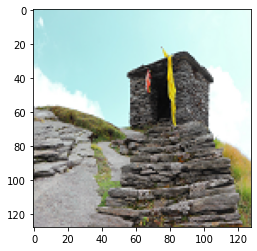

In [1]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
img = cv.imread("./128x128.png")
img_gray = cv.imread("./128x128.png", cv.IMREAD_GRAYSCALE)
img_resize = cv.resize(img_gray, (64, 64))
print(img.dtype)
img_dis = cv.cvtColor(img,cv.COLOR_BGR2RGB)
plt.imshow(img_dis)


###  Loading Overlay

The Overlay module encapsulates the interface for the ARM CPU to interact with the PL part of the FPGA.

- We can load the hardware design we just generated onto the PL with the simple `Overlay()` method
- With the `overlay.sobel_accel_0` statement, we can interact with the IP in the form of an accessed Python object

In [ ]:
from pynq import allocate,Overlay
import numpy as np

rows_in, cols_in, channel_in = img.shape

pixel_size_in = rows_in*cols_in

rows_out = 64
cols_out = 64
pixel_size_out = rows_out*cols_out

overlay = Overlay("./sobelAll1211.bit")

sobel = overlay.sobel_accel_0
resize = overlay.resize_accel_0
cvtcolor =overlay.cvtcolor_bgr2gray_0

### Allocating memory for IP use

The `pynq.allocate` function is used to allocate memory space that can be used by the IP in PL.

- Before the IP in PL can access DRAM, some memory must be reserved for it to be used by the IP, allocating size and address.

- We allocate memory for each of the three parts: input, output and weight, with data type uint8. You can use data type strings **'u1'**, or just simply use `np.uint8`. 

- pynq.allocate` will allocate physically contiguous memory and return a `pynq.Buffer` indicating the object that has been allocated a buffer.

In [ ]:
from pynq import allocate
import numpy as np

rows_in, cols_in, channel_in = img.shape

pixel_size_in = rows_in*cols_in

pixel_size_out = rows_out*cols_out


cvtcolor_input_buffer = allocate(shape=(rows_in*cols_in*3, ),dtype=np.uint8)
cvtcolor_output_buffer = allocate(shape=(rows_in* cols_in, ),dtype=np.uint8)
cvtcolor_output_buffer[:] = 255 

resize_input_buffer = allocate(shape=(pixel_size_in,), dtype=np.uint8)
resize_output_buffer = allocate(shape=(pixel_size_out,), dtype=np.uint8)

sobel_input_buffer = allocate(shape=(pixel_size_out, ), dtype=np.uint8)
sobel_output_buffer_1 = allocate(shape=(pixel_size_out,),dtype=np.uint8)
sobel_output_buffer_2 = allocate(shape=(pixel_size_out,),dtype=np.uint8)
print("Buffer allocation done!")

done


### Configuring IP

We can print the register map of the IP object, so that we will see the input and output ports of the IP.

We can use the `write` method of the IP directly to write the address of the just allocated memory space to the corresponding location of the IP.




In [5]:
print(sobel.register_map)
print(resize.register_map)
print(cvtcolor.register_map)
# print(sobel.register_map.img_inp_1.address)

RegisterMap {
  CTRL = Register(AP_START=0, AP_DONE=0, AP_IDLE=1, AP_READY=0, RESERVED_1=0, AUTO_RESTART=0, RESERVED_2=0, INTERRUPT=0, RESERVED_3=0),
  GIER = Register(Enable=0, RESERVED=0),
  IP_IER = Register(CHAN0_INT_EN=0, CHAN1_INT_EN=0, RESERVED_0=0),
  IP_ISR = Register(CHAN0_INT_ST=0, CHAN1_INT_ST=0, RESERVED_0=0),
  img_inp_1 = Register(img_inp=write-only),
  img_inp_2 = Register(img_inp=write-only),
  img_out1_1 = Register(img_out1=write-only),
  img_out1_2 = Register(img_out1=write-only),
  img_out2_1 = Register(img_out2=write-only),
  img_out2_2 = Register(img_out2=write-only),
  rows = Register(rows=write-only),
  cols = Register(cols=write-only)
}
RegisterMap {
  CTRL = Register(AP_START=0, AP_DONE=0, AP_IDLE=1, AP_READY=0, RESERVED_1=0, AUTO_RESTART=0, RESERVED_2=0, INTERRUPT=0, RESERVED_3=0),
  GIER = Register(Enable=0, RESERVED=0),
  IP_IER = Register(CHAN0_INT_EN=0, CHAN1_INT_EN=0, RESERVED_0=0),
  IP_ISR = Register(CHAN0_INT_ST=0, CHAN1_INT_ST=0, RESERVED_0=0),
  img

### Use the cvtcolor kernel

In [6]:
np.copyto(cvtcolor_input_buffer, img.flatten())

cvtcolor.write(cvtcolor.register_map.imgInput_1.address, cvtcolor_input_buffer.physical_address)
cvtcolor.write(cvtcolor.register_map.imgOutput_1.address, cvtcolor_output_buffer.physical_address)



In [7]:
import time

start_time = time.time()
cvtcolor.register_map.CTRL.AP_START=1

cnt = 0
while True:
    reg = cvtcolor.register_map.CTRL.AP_DONE
    if reg == 1:
        print("###", reg)
        break


end_time = time.time()

print("Duration：{}s".format(end_time - start_time))

### 1
Duration：0.014776945114135742s


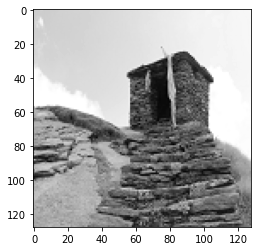

In [8]:
cvtcolor_output_buffer_dis = cvtcolor_output_buffer.reshape(rows_in, cols_in)
plt.imshow(cvtcolor_output_buffer_dis, cmap="gray")

### Use the resize kernel

In [9]:

np.copyto(resize_input_buffer, cvtcolor_output_buffer)


In [10]:
resize.register_map

RegisterMap {
  CTRL = Register(AP_START=0, AP_DONE=0, AP_IDLE=1, AP_READY=0, RESERVED_1=0, AUTO_RESTART=0, RESERVED_2=0, INTERRUPT=0, RESERVED_3=0),
  GIER = Register(Enable=0, RESERVED=0),
  IP_IER = Register(CHAN0_INT_EN=0, CHAN1_INT_EN=0, RESERVED_0=0),
  IP_ISR = Register(CHAN0_INT_ST=0, CHAN1_INT_ST=0, RESERVED_0=0),
  img_inp_1 = Register(img_inp=write-only),
  img_inp_2 = Register(img_inp=write-only),
  img_out_1 = Register(img_out=write-only),
  img_out_2 = Register(img_out=write-only),
  rows_in = Register(rows_in=write-only),
  cols_in = Register(cols_in=write-only),
  rows_out = Register(rows_out=write-only),
  cols_out = Register(cols_out=write-only)
}

In [11]:
resize.write(resize.register_map.img_inp_1.address, resize_input_buffer.physical_address)
resize.write(resize.register_map.img_out_1.address, resize_output_buffer.physical_address)
resize.register_map.rows_in = rows_in
resize.register_map.cols_in = cols_in
resize.register_map.rows_out = rows_out
resize.register_map.cols_out = cols_out


In [12]:
# print(resize.register_map.CTRL)

In [ ]:
import time

start_time = time.time()
resize.register_map.CTRL.AP_START=1

cnt = 0
while True:
    reg = resize.register_map.CTRL.AP_DONE

    if reg == 1:
        print("###", reg)
        break
    cnt += 1



end_time = time.time()

print("Duration：{}s".format(end_time - start_time))

### 1
Duration：0.0017549991607666016s


In [14]:
print(resize.register_map.CTRL)
print(f"{resize_input_buffer.physical_address:x}")
print(f"{resize_output_buffer.physical_address:x}")
print(img.shape)
print(resize.register_map)

0x4
379c0000
2b09000
(128, 128, 3)
RegisterMap {
  CTRL = Register(AP_START=0, AP_DONE=0, AP_IDLE=1, AP_READY=0, RESERVED_1=0, AUTO_RESTART=0, RESERVED_2=0, INTERRUPT=0, RESERVED_3=0),
  GIER = Register(Enable=0, RESERVED=0),
  IP_IER = Register(CHAN0_INT_EN=0, CHAN1_INT_EN=0, RESERVED_0=0),
  IP_ISR = Register(CHAN0_INT_ST=0, CHAN1_INT_ST=0, RESERVED_0=0),
  img_inp_1 = Register(img_inp=write-only),
  img_inp_2 = Register(img_inp=write-only),
  img_out_1 = Register(img_out=write-only),
  img_out_2 = Register(img_out=write-only),
  rows_in = Register(rows_in=write-only),
  cols_in = Register(cols_in=write-only),
  rows_out = Register(rows_out=write-only),
  cols_out = Register(cols_out=write-only)
}


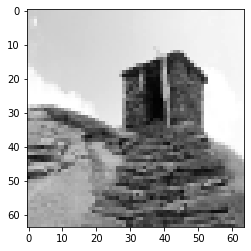

In [15]:
resize_output_buffer_dis = resize_output_buffer.reshape(rows_out, cols_out)
plt.imshow(resize_output_buffer_dis, cmap="gray")

### Use the sobel kernel

In [16]:
sobel.register_map

RegisterMap {
  CTRL = Register(AP_START=0, AP_DONE=0, AP_IDLE=1, AP_READY=0, RESERVED_1=0, AUTO_RESTART=0, RESERVED_2=0, INTERRUPT=0, RESERVED_3=0),
  GIER = Register(Enable=0, RESERVED=0),
  IP_IER = Register(CHAN0_INT_EN=0, CHAN1_INT_EN=0, RESERVED_0=0),
  IP_ISR = Register(CHAN0_INT_ST=0, CHAN1_INT_ST=0, RESERVED_0=0),
  img_inp_1 = Register(img_inp=write-only),
  img_inp_2 = Register(img_inp=write-only),
  img_out1_1 = Register(img_out1=write-only),
  img_out1_2 = Register(img_out1=write-only),
  img_out2_1 = Register(img_out2=write-only),
  img_out2_2 = Register(img_out2=write-only),
  rows = Register(rows=write-only),
  cols = Register(cols=write-only)
}

In [17]:
np.copyto(sobel_input_buffer, resize_output_buffer)

sobel_output_buffer_1[:] = 255
sobel_output_buffer_2[:] = 255
print(np.all(sobel_output_buffer_1 == 255))
sobel_output_buffer_1[0:64*32] = 0
sobel_output_buffer_2[64*32:] = 0

sobel_input_buffer.flush()


sobel.write(sobel.register_map.img_inp_1.address, sobel_input_buffer.physical_address)
sobel.write(sobel.register_map.img_out1_1.address, sobel_output_buffer_1.physical_address)
sobel.write(sobel.register_map.img_out2_1.address, sobel_output_buffer_2.physical_address)
sobel.rows=rows_out
sobel.cols=rows_out

True


In [ ]:

import time

# cvtcolor.write(0x00, 0x01)
start_time = time.time()
sobel.register_map.CTRL.AP_START=1

cnt = 0
while True:
    reg = sobel.register_map.CTRL.AP_DONE
    cnt+=1
    if reg == 1:
        print("###", reg, "###", cnt)
        break
    


end_time = time.time()

print("Duration：{}s".format(end_time - start_time))

### 1 ### 1
Duration：0.0011739730834960938s


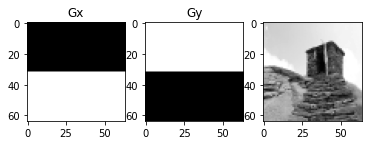

In [22]:


# print(sobel_output_buffer_1[32,:])
plt.subplot(131)
plt.title("Gx")
plt.imshow(sobel_output_buffer_1.reshape(rows_out, cols_out), cmap="gray")
plt.subplot(132)
plt.title("Gy")
plt.imshow(sobel_output_buffer_2.reshape(rows_out,cols_out), cmap="gray")
plt.subplot(133)
plt.imshow(sobel_input_buffer.reshape(rows_out,cols_out), cmap="gray")

---------------------------------------
<p align="center">Copyright&copy; 2024 Advanced Micro Devices</p>